<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-1-Manifold-Learning/Untitled143.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Manifold Learning: Implicit Representation**

**The hyperboloid** Our goal is to
learn an implicit representation of this surface from point cloud data obtained from the standard parametrization

\begin{aligned}
x(u,v) &= \cosh(u)\,\cos(v),\\[4pt]
y(u,v) &= \frac{1}{\sqrt{2}}\,\cosh(u)\,\sin(v),\\[4pt]
z(u,v) &= \sinh(u),
\end{aligned}
$u\in [-2, 2], \; v\in[0,2\pi)$.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,641 (33.75 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 0 (0.00 B)

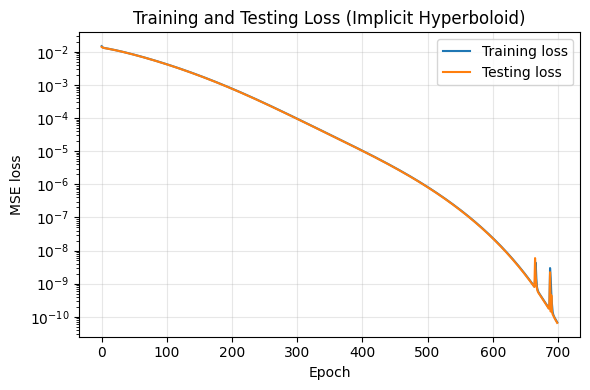

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


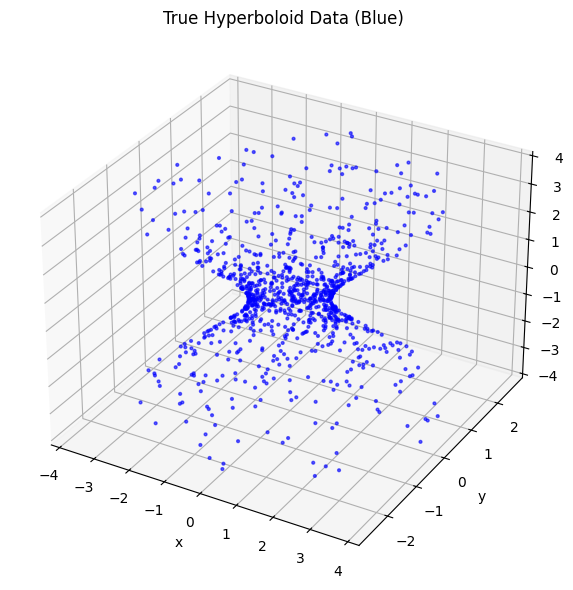

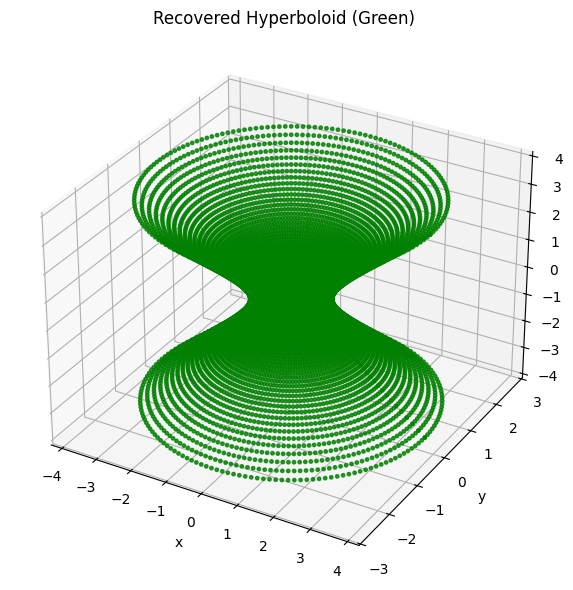

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# -------------------------------------------------------------------
# 1. Generate synthetic data on the hyperboloid x^2 + 2y^2 - z^2 = 1
# -------------------------------------------------------------------

def sample_hyperboloid(N=1000, u_min=-2.0, u_max=2.0, seed=0):
    rng = np.random.default_rng(seed)
    u = rng.uniform(u_min, u_max, size=N)
    v = rng.uniform(0.0, 2.0 * np.pi, size=N)

    x = np.cosh(u) * np.cos(v)
    y = (1.0 / np.sqrt(2.0)) * np.cosh(u) * np.sin(v)
    z = np.sinh(u)

    X = np.stack([x, y, z], axis=1)  # shape (N, 3)
    return X

N = 1000
X = sample_hyperboloid(N=N)

# Targets: implicit surface => f(x,y,z)=0 on data
y_target = np.zeros((N, 1), dtype=np.float32)

# -------------------------------------------------------------------
# 2. Train / test split (80% / 20%)
# -------------------------------------------------------------------
N_train = int(0.8 * N)
indices = np.random.permutation(N)
train_idx = indices[:N_train]
test_idx  = indices[N_train:]

X_train = X[train_idx]
y_train = y_target[train_idx]
X_test  = X[test_idx]
y_test  = y_target[test_idx]

# -------------------------------------------------------------------
# 3. Build the neural network f_theta(x,y,z)
# -------------------------------------------------------------------
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(64, activation='swish',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(64, activation='swish',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(64, activation='swish',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(1)  # scalar output f_theta(x,y,z)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="mse",           # L_data; L_reg via kernel_regularizer
        metrics=["mse"]
    )
    return model

model = build_model()
model.summary()

# -------------------------------------------------------------------
# 4. Train the model and store history (training & testing loss)
# -------------------------------------------------------------------
EPOCHS = 700   # <- updated to 1000 epochs
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# -------------------------------------------------------------------
# 5. Plot training and testing loss curves
# -------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Testing loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and Testing Loss (Implicit Hyperboloid)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 6. Visualize true data (blue) and recovered hyperboloid (green)
#    on separate graphs
# -------------------------------------------------------------------

# Dense param grid for visualization
u_vis = np.linspace(-2.0, 2.0, 80)
v_vis = np.linspace(0.0, 2.0 * np.pi, 160)
U, V = np.meshgrid(u_vis, v_vis)
u_flat = U.ravel()
v_flat = V.ravel()

x_vis = np.cosh(u_flat) * np.cos(v_flat)
y_vis = (1.0 / np.sqrt(2.0)) * np.cosh(u_flat) * np.sin(v_flat)
z_vis = np.sinh(u_flat)

X_vis = np.stack([x_vis, y_vis, z_vis], axis=1)

# Evaluate implicit function
f_pred = model.predict(X_vis, batch_size=1024).ravel()

# Keep points close to the learned zero level set
eps = 0.05
mask = np.abs(f_pred) < eps
X_rec = X_vis[mask]

# --- Graph 1: true data points in blue ---
fig1 = plt.figure(figsize=(7,6))
ax1 = fig1.add_subplot(111, projection="3d")
ax1.scatter(X[:,0], X[:,1], X[:,2], s=4, c="blue", alpha=0.6)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("True Hyperboloid Data (Blue)")
plt.tight_layout()
plt.show()

# --- Graph 2: recovered hyperboloid points in green ---
fig2 = plt.figure(figsize=(7,6))
ax2 = fig2.add_subplot(111, projection="3d")
ax2.scatter(X_rec[:,0], X_rec[:,1], X_rec[:,2], s=6, c="green", alpha=0.8)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_title("Recovered Hyperboloid (Green)")
plt.tight_layout()
plt.show()
